# 1.美国2012年总统候选人政治献金数据分析

In [1]:
import numpy as np
import pandas as pd

In [2]:
import os

In [3]:
os.listdir('usa_elect/') # 使用os.listdir()函数查看当前目录下的文件和文件夹，确认数据文件是否存在

['party.xlsx', 'contb_02.csv', 'contb_03.csv', 'contb_01.csv']

In [4]:
contdf_list = [] # 创建一个空列表，用于存储读取的数据文件
for fname in os.listdir('usa_elect/'):
    if fname.endswith('.csv'): # 判断文件是否以.csv结尾
        print(f"正在读取CSV文件: {fname}") # 打印提示信息，表示正在读取CSV文件
        df = pd.read_csv('usa_elect/' + fname) # 使用pandas的read_csv()函数读取数据文件
        contdf_list.append(df) # 将读取的数据文件添加到列表中
    elif fname.endswith('.xlsx'): # 判断文件是否以.xlsx结尾
        print(f"正在读取Excel文件: {fname}") # 打印提示信息，表示正在读取Excel文件
        party_df = pd.read_excel('usa_elect/' + fname) # 使用pandas的read_excel()函数读取数据文件
    else:
        print(f"文件 {fname} 不是CSV或Excel文件,无法读取。") # 如果文件不是CSV或Excel文件，打印提示信息

正在读取Excel文件: party.xlsx
正在读取CSV文件: contb_02.csv
正在读取CSV文件: contb_03.csv
正在读取CSV文件: contb_01.csv


In [5]:
party_df.head() # 使用head()函数查看数据的前几行，确认数据是否正确读取

,cand_nm,party
0,"Bachmann, Michelle",Republican
1,"Cain, Herman",Republican
2,"Gingrich, Newt",Republican
3,"Huntsman, Jon",Republican
4,"Johnson, Gary Earl",Libertarian


In [6]:
contdf_list[0].head() # 使用head()函数查看数据的前几行，确认数据是否正确读取

,cand_nm,contbr_nm,contbr_st,contbr_employer,contbr_occupation,contb_receipt_amt,contb_receipt_dt
0,"Obama, Barack","COX, JAMES E",IL,EAGLE RIDGE REALTY,SALES,25.0,09-DEC-11
1,"Obama, Barack","RAINEY, HENRY",IL,RETIRED,RETIRED,100.0,22-DEC-11
2,"Obama, Barack","FAHEY WALLENIUS, SHEILA",IL,NM,LEGAL,5.0,30-NOV-11
3,"Obama, Barack","DUMAS, ROBERT",IL,INFORMATION REQUESTED,INFORMATION REQUESTED,62.0,06-DEC-11
4,"Obama, Barack","HESS, JONATHAN",IL,"GERIATRIC CARE ASSOCIATES, INC.",CLINICAL NEUROPSYCHOLOGIST,10.0,09-OCT-11


In [7]:
contd = pd.concat(contdf_list, axis=0, ignore_index=True) # 使用pandas的concat()函数将列表中的数据文件按行合并为一个DataFrame

In [8]:
# 查看文件样式及基本信息
contd.info() # 使用info()函数查看数据的基本信息，包括数据类型、非空值数量等

<class 'pandas.DataFrame'>
RangeIndex: 1001733 entries, 0 to 1001732
Data columns (total 7 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   cand_nm            1001733 non-null  str    
 1   contbr_nm          1001733 non-null  str    
 2   contbr_st          1001729 non-null  str    
 3   contbr_employer    988004 non-null   str    
 4   contbr_occupation  993303 non-null   str    
 5   contb_receipt_amt  1001733 non-null  float64
 6   contb_receipt_dt   1001733 non-null  str    
dtypes: float64(1), str(6)
memory usage: 53.5 MB


In [9]:
party_df.info() # 使用info()函数查看数据的基本信息，包括数据类型、非空值数量等

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   cand_nm  13 non-null     str  
 1   party    13 non-null     str  
dtypes: str(2)
memory usage: 340.0 bytes


## 新建一列各个候选人所在党派party

In [10]:
contd

,cand_nm,contbr_nm,contbr_st,contbr_employer,contbr_occupation,contb_receipt_amt,contb_receipt_dt
0,"Obama, Barack","COX, JAMES E",IL,EAGLE RIDGE REALTY,SALES,25.0,09-DEC-11
1,"Obama, Barack","RAINEY, HENRY",IL,RETIRED,RETIRED,100.0,22-DEC-11
2,"Obama, Barack","FAHEY WALLENIUS, SHEILA",IL,NM,LEGAL,5.0,30-NOV-11
3,"Obama, Barack","DUMAS, ROBERT",IL,INFORMATION REQUESTED,INFORMATION REQUESTED,62.0,06-DEC-11
4,"Obama, Barack","HESS, JONATHAN",IL,"GERIATRIC CARE ASSOCIATES, INC.",CLINICAL NEUROPSYCHOLOGIST,10.0,09-OCT-11
...,...,...,...,...,...,...,...
1001728,"Obama, Barack","LONG, JOE",IL,CTS,QUALITY CONTROL,35.0,24-NOV-11
1001729,"Obama, Barack","SLABY, MICHAEL J",IL,OBAMA FOR AMERICA,CIIO,100.0,19-OCT-11
1001730,"Obama, Barack","BOSGRAAF, ROB",IL,SELF-EMPLOYED,ENTREPRENEUR,342.0,01-DEC-11
1001731,"Obama, Barack","STIENS, SALLIE",IL,GRANT THORNTON LLP,MANAGER GLOBAL CLIENT SERVICE,50.0,28-NOV-11


In [11]:
party_df

,cand_nm,party
0,"Bachmann, Michelle",Republican
1,"Cain, Herman",Republican
2,"Gingrich, Newt",Republican
3,"Huntsman, Jon",Republican
4,"Johnson, Gary Earl",Libertarian
5,"McCotter, Thaddeus G",Republican
6,"Obama, Barack",Democrat
7,"Paul, Ron",Republican
8,"Pawlenty, Timothy",Republican
9,"Perry, Rick",Republican


In [12]:
contd['cand_nm'].unique() # 使用unique()函数查看候选人名称的唯一值，确认数据是否正确读取

<StringArray>
[                 'Obama, Barack', 'Roemer, Charles E. 'Buddy' III',
              'Pawlenty, Timothy',             'Johnson, Gary Earl',
                      'Paul, Ron',                 'Santorum, Rick',
                   'Cain, Herman',                 'Gingrich, Newt',
             'Bachmann, Michelle',           'McCotter, Thaddeus G',
                  'Huntsman, Jon',                    'Perry, Rick',
                   'Romney, Mitt']
Length: 13, dtype: str

In [13]:
# 合并数据集
merged_df = pd.merge(contd, party_df, how='outer', left_on='cand_nm', right_on='cand_nm') # 使用pandas的merge()函数将两个数据集按候选人名称进行合并，使用outer连接方式

In [14]:
merged_df.head() # 使用head()函数查看合并后的数据的前几行，确认数据是否正确合并

,cand_nm,contbr_nm,contbr_st,contbr_employer,contbr_occupation,contb_receipt_amt,contb_receipt_dt,party
0,"Bachmann, Michelle","HOCKING, WAYNE",AE,LOCKHEED MARTIN,ENGINEER,1000.0,24-JUN-11,Republican
1,"Bachmann, Michelle","ROBERT, KILLEY",AE,U.S. ARMY CORPS OF ENGINEERS,STRUCTURAL ENGINEER,250.0,01-OCT-11,Republican
2,"Bachmann, Michelle","GRUSSING, MICHAEL",AE,DOD,GOV EMPLOYEE,500.0,28-NOV-11,Republican
3,"Bachmann, Michelle","HUGHES, PHIL",AK,SELF,CONSULTANT,82.5,19-AUG-11,Republican
4,"Bachmann, Michelle","SCHLIESING, MYRA",AK,NaN,RETIRED,250.0,30-JUN-11,Republican


In [15]:
#查看party列的唯一值
merged_df['party'].unique() # 使用unique()函数查看party列的唯一值，确认数据是否正确合并

<StringArray>
['Republican', 'Libertarian', 'Democrat', 'Reform']
Length: 4, dtype: str

In [16]:
# 统计party列中每个党派的数量
party_counts = merged_df['party'].value_counts() # 使用value_counts()函数统计party列中每个党派的数量
party_counts # 打印党派数量统计结果

party
Democrat       593748
Republican     400831
Reform           5920
Libertarian      1234
Name: count, dtype: int64

In [17]:
#查看各个党派的政治献金总额
merged_df.groupby('party')['contb_receipt_amt'].sum() # 使用groupby()函数按党派分组，并使用sum()函数计算每个党派的政治献金总额

party
Democrat       1.335027e+08
Libertarian    5.669616e+05
Reform         3.674575e+05
Republican     1.643144e+08
Name: contb_receipt_amt, dtype: float64

In [18]:
import matplotlib.pyplot as plt

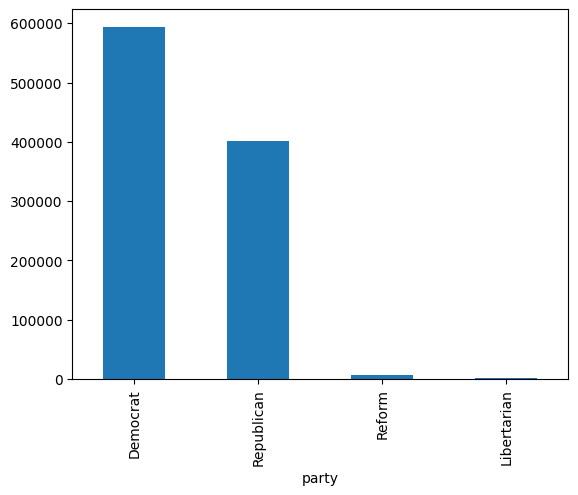

In [19]:
# 可视化
party_counts = merged_df['party'].value_counts().plot(kind='bar') # 使用plot()函数绘制柱状图，显示每个党派的数量

## 查看具体每天各个党派收到的政治献金

In [20]:
merged_df.info() # 使用info()函数查看合并后的数据集的基本信息，包括数据类型、非空值数量等

<class 'pandas.DataFrame'>
RangeIndex: 1001733 entries, 0 to 1001732
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   cand_nm            1001733 non-null  str    
 1   contbr_nm          1001733 non-null  str    
 2   contbr_st          1001729 non-null  str    
 3   contbr_employer    988004 non-null   str    
 4   contbr_occupation  993303 non-null   str    
 5   contb_receipt_amt  1001733 non-null  float64
 6   contb_receipt_dt   1001733 non-null  str    
 7   party              1001733 non-null  str    
dtypes: float64(1), str(7)
memory usage: 61.1 MB


In [21]:
merged_df['contb_receipt_dt']

0          24-JUN-11
1          01-OCT-11
2          28-NOV-11
3          19-AUG-11
4          30-JUN-11
             ...    
1001728    21-FEB-12
1001729    28-FEB-12
1001730    21-FEB-12
1001731    27-FEB-12
1001732    30-APR-12
Name: contb_receipt_dt, Length: 1001733, dtype: str

In [22]:
# 备注：24-JUN-11可以通过pd.to_datetime()函数将字符串转换为日期时间格式
pd.to_datetime("24-JUN-11") # 使用pd.to_datetime()函数将字符串转换为日期时间格式

Timestamp('2011-06-24 00:00:00')

## 查看日期格式，并将其转换为pandas的日期时间格式，通过函数map方式进行转换

In [23]:
month_dict = {
    'JAN': 1,
    'FEB': 2,
    'MAR': 3,
    'APR': 4,
    'MAY': 5,
    'JUN': 6,
    'JUL': 7,
    'AUG': 8,   
    'SEP': 9,
    'OCT': 10,
    'NOV': 11,
    'DEC': 12
}

In [24]:
# '24-JUN-11' -> '2011-06-24'
def convert_date(date_str):
    # 判断输入是否为字符串类型
    if isinstance(date_str, str):
        day, month, year = date_str.split('-') # 将字符串按'-'分割为列表
        month = month_dict[month] # 使用字典将月份缩写转换为数字
        return f"20{year}-{month:02d}-{day}" # 返回格式化后的日期字符串

In [25]:
convert_date('24-JUN-11')

'2011-06-24'

In [26]:
date_string = merged_df['contb_receipt_dt'].map(convert_date) # 使用map()函数将convert_date()函数应用于contb_receipt_dt列的每个元素，实现日期格式的转换

In [28]:
merged_df['contb_receipt_dt'] = pd.to_datetime(date_string) # 使用pd.to_datetime()函数将转换后的日期字符串转换为pandas的日期时间格式，并赋值给contb_receipt_dt列

In [30]:
# 查看是否转换成功
merged_df.info() # 使用info()函数查看合并后的数据集的基本信息，包括数据类型、非空值数量等 

<class 'pandas.DataFrame'>
RangeIndex: 1001733 entries, 0 to 1001732
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   cand_nm            1001733 non-null  str           
 1   contbr_nm          1001733 non-null  str           
 2   contbr_st          1001729 non-null  str           
 3   contbr_employer    988004 non-null   str           
 4   contbr_occupation  993303 non-null   str           
 5   contb_receipt_amt  1001733 non-null  float64       
 6   contb_receipt_dt   1001733 non-null  datetime64[us]
 7   party              1001733 non-null  str           
dtypes: datetime64[us](1), float64(1), str(6)
memory usage: 61.1 MB


In [32]:
# 根据时间进行排序
merged_df.sort_values(by='contb_receipt_dt', inplace=True) # 使用sort_values()函数按contb_receipt_dt列进行排序，并使用inplace=True参数直接修改原始数据集

## 查看每一天各个党派收到的政治献金总额

In [35]:
grouped_df = merged_df.groupby(by = ['contb_receipt_dt', 'party'])['contb_receipt_amt'].sum()# 使用groupby()函数按日期和党派分组，并使用sum()函数计算每个组的政治献金总额

## 使用unstack()函数将上面所得数据的party从索引变为列，方便后续绘图

In [36]:
grouped_df

contb_receipt_dt  party     
2011-01-01        Republican       8600.00
2011-01-03        Republican       4800.00
2011-01-04        Republican       5000.00
2011-01-12        Republican       4150.00
2011-01-13        Republican       4000.00
                                   ...    
2012-04-29        Democrat       349744.69
                  Republican      61421.02
2012-04-30        Democrat      3499159.38
                  Reform             35.00
                  Republican     787702.81
Name: contb_receipt_amt, Length: 1550, dtype: float64

In [44]:
grouped_df = grouped_df.unstack() # 使用unstack()函数将上面所得数据的party从索引变为列，方便后续绘图

In [45]:
grouped_df

party,Democrat,Libertarian,Reform,Republican
contb_receipt_dt,,,,
2011-01-01,NaN,NaN,NaN,8600.00
2011-01-03,NaN,NaN,NaN,4800.00
2011-01-04,NaN,NaN,NaN,5000.00
2011-01-12,NaN,NaN,NaN,4150.00
2011-01-13,NaN,NaN,NaN,4000.00
...,...,...,...,...
2012-04-26,537115.38,1805.0,25.0,505311.33
2012-04-27,745269.95,350.0,560.0,593983.56
2012-04-28,479677.34,NaN,110.0,80759.16


In [46]:
grouped_df.fillna(value=0, inplace=True) # 使用fillna()函数将缺失值填充为0，并使用inplace=True参数直接修改原始数据集

party,Democrat,Libertarian,Reform,Republican
contb_receipt_dt,,,,
2011-01-01,0.00,0.0,0.0,8600.00
2011-01-03,0.00,0.0,0.0,4800.00
2011-01-04,0.00,0.0,0.0,5000.00
2011-01-12,0.00,0.0,0.0,4150.00
2011-01-13,0.00,0.0,0.0,4000.00
...,...,...,...,...
2012-04-26,537115.38,1805.0,25.0,505311.33
2012-04-27,745269.95,350.0,560.0,593983.56
2012-04-28,479677.34,0.0,110.0,80759.16


<Axes: xlabel='contb_receipt_dt'>

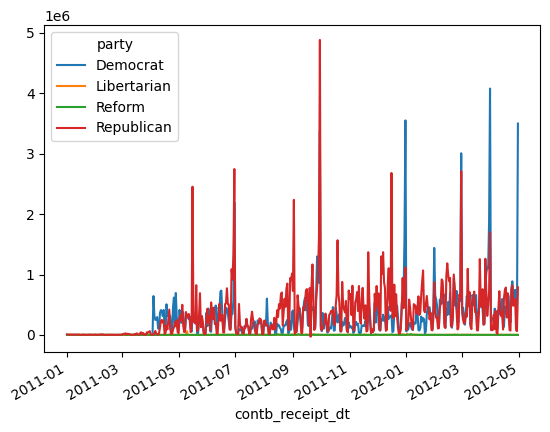

In [47]:
grouped_df.plot(kind='line')

party,Democrat,Libertarian,Reform,Republican
contb_receipt_dt,,,,
2011-01-01,0.000000e+00,0.0,0.00,8.600000e+03
2011-01-03,0.000000e+00,0.0,0.00,1.340000e+04
2011-01-04,0.000000e+00,0.0,0.00,1.840000e+04
2011-01-12,0.000000e+00,0.0,0.00,2.255000e+04
2011-01-13,0.000000e+00,0.0,0.00,2.655000e+04
...,...,...,...,...
2012-04-26,1.284288e+08,566611.6,366752.54,1.627905e+08
2012-04-27,1.291741e+08,566961.6,367312.54,1.633845e+08
2012-04-28,1.296538e+08,566961.6,367422.54,1.634653e+08


<Axes: xlabel='contb_receipt_dt'>

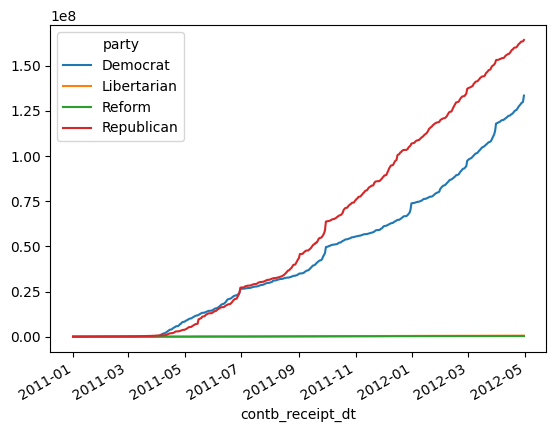

In [ ]:
# 画出各党派累计政治献金，cumsum（）累加函数
grouped_df = grouped_df.cumsum() # cumsum()函数是用于计算累计和的函数，可以对每个党派的政治献金进行累加，得到每个党派在每个时间点的累计政治献金总额
display(grouped_df)
grouped_df.plot(kind='line')

In [58]:
# 把时间作为列，党派作为行来观察
grouped_df.T

contb_receipt_dt,2011-01-01,2011-01-03,2011-01-04,2011-01-12,2011-01-13,2011-01-14,2011-01-15,2011-01-16,2011-01-17,2011-01-18,...,2012-04-21,2012-04-22,2012-04-23,2012-04-24,2012-04-25,2012-04-26,2012-04-27,2012-04-28,2012-04-29,2012-04-30
party,,,,,,,,,,,,,,,,,,,,,
Democrat,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.253251e+08,1.255359e+08,1.263071e+08,1.271945e+08,1.278917e+08,1.284288e+08,1.291741e+08,1.296538e+08,1.300035e+08,1.335027e+08
Libertarian,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.547765e+05,5.605615e+05,5.615615e+05,5.620615e+05,5.648066e+05,5.666116e+05,5.669616e+05,5.669616e+05,5.669616e+05,5.669616e+05
Reform,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.659925e+05,3.660925e+05,3.666025e+05,3.666275e+05,3.667275e+05,3.667525e+05,3.673125e+05,3.674225e+05,3.674225e+05,3.674575e+05
Republican,8600.0,13400.0,18400.0,22550.0,26550.0,32550.0,33050.0,33800.0,34300.0,39100.0,...,1.601691e+08,1.602404e+08,1.609832e+08,1.618031e+08,1.622852e+08,1.627905e+08,1.633845e+08,1.634653e+08,1.635267e+08,1.643144e+08


In [60]:
# 使用stack()函数将party列从列索引变为二级行索引
grouped_df

party,Democrat,Libertarian,Reform,Republican
contb_receipt_dt,,,,
2011-01-01,0.000000e+00,0.0,0.00,8.600000e+03
2011-01-03,0.000000e+00,0.0,0.00,1.340000e+04
2011-01-04,0.000000e+00,0.0,0.00,1.840000e+04
2011-01-12,0.000000e+00,0.0,0.00,2.255000e+04
2011-01-13,0.000000e+00,0.0,0.00,2.655000e+04
...,...,...,...,...
2012-04-26,1.284288e+08,566611.6,366752.54,1.627905e+08
2012-04-27,1.291741e+08,566961.6,367312.54,1.633845e+08
2012-04-28,1.296538e+08,566961.6,367422.54,1.634653e+08


In [61]:
grouped_df.stack() # 使用unstack()函数将上面所得数据的party从索引变为列，方便后续绘图

contb_receipt_dt  party      
2011-01-01        Democrat       0.000000e+00
                  Libertarian    0.000000e+00
                  Reform         0.000000e+00
                  Republican     8.600000e+03
2011-01-03        Democrat       0.000000e+00
                                     ...     
2012-04-29        Republican     1.635267e+08
2012-04-30        Democrat       1.335027e+08
                  Libertarian    5.669616e+05
                  Reform         3.674575e+05
                  Republican     1.643144e+08
Length: 1864, dtype: float64

In [62]:
# 查看候选人姓名和政治献金捐献者职业，以及捐献情况。
merged_df.groupby(by = ['cand_nm', 'contbr_occupation'])['contb_receipt_amt'].sum() # 使用groupby()函数按候选人姓名和捐献者职业分组，并使用sum()函数计算每个组的政治献金总额

cand_nm             contbr_occupation             
Bachmann, Michelle  --                                  75.00
                    100% DISABLED VETERAN             1869.50
                    100% DISABLED VIETNAM VETERAN      236.25
                    A/C AND HEAT                       250.00
                    ACADEMIC EMPLOYMENT SPECIALIST      25.00
                                                       ...   
Santorum, Rick      WRITER/PROFESSOR                   910.00
                    X-RAY TECHNICIAN                  2500.00
                    XRAY TECH                          380.00
                    YOUTH MINISTER                     475.00
                    YOUTH MINISTRY                     250.00
Name: contb_receipt_amt, Length: 59313, dtype: float64

In [64]:
#查看DISABLED VETERAN主要支持谁
merged_df['contbr_occupation'] == 'DISABLED VETERAN'

31791      False
31790      False
33090      False
33091      False
31792      False
           ...  
284349     False
391584     False
284353     False
594869     False
1001732    False
Name: contbr_occupation, Length: 1001733, dtype: bool

In [69]:
dis = merged_df[merged_df['contbr_occupation'] == 'DISABLED VETERAN']
dis

,cand_nm,contbr_nm,contbr_st,contbr_employer,contbr_occupation,contb_receipt_amt,contb_receipt_dt,party
155158,"Obama, Barack","DEKLE, CHARLES R.",MD,RETIRED,DISABLED VETERAN,160.0,2011-04-27,Democrat
736475,"Paul, Ron","THORNELL, GARY ENOS MR.",KY,NONE,DISABLED VETERAN,201.2,2011-06-05,Republican
21468,"Cain, Herman","ANDERSON, JOSEPH",GA,NONE,DISABLED VETERAN,100.0,2011-06-18,Republican
155159,"Obama, Barack","DEKLE, CHARLES R.",MD,RETIRED,DISABLED VETERAN,160.0,2011-06-23,Democrat
116132,"Obama, Barack","BAUER, JOSEPH",KY,NOT EMPLOYED,DISABLED VETERAN,100.0,2011-07-08,Democrat
...,...,...,...,...,...,...,...,...
660140,"Obama, Barack","ALLBEE, DWIGHT",IA,DISABLED,DISABLED VETERAN,25.0,2012-04-30,Democrat
507668,"Obama, Barack","PERITZ, EDWARD B",CA,RETIRED,DISABLED VETERAN,100.0,2012-04-30,Democrat
325902,"Obama, Barack","ROBERTS, GORDON",OR,NOT EMPLOYED,DISABLED VETERAN,40.0,2012-04-30,Democrat
218509,"Obama, Barack","RORIE, FOREST",NC,DISABLED,DISABLED VETERAN,20.0,2012-04-30,Democrat


In [74]:
good = dis['cand_nm'].value_counts() # 使用value_counts()函数统计DISABLED VETERAN职业的捐献者主要支持的候选人
good

cand_nm
Obama, Barack                     97
Paul, Ron                         46
Santorum, Rick                     6
Cain, Herman                       3
Roemer, Charles E. 'Buddy' III     1
Gingrich, Newt                     1
Name: count, dtype: int64

In [78]:
# 把索引变成列索引，reset_index()函数可以将索引变为列索引
good_df = good.reset_index()
good_df

,cand_nm,count
0,"Obama, Barack",97
1,"Paul, Ron",46
2,"Santorum, Rick",6
3,"Cain, Herman",3
4,"Roemer, Charles E. 'Buddy' III",1
5,"Gingrich, Newt",1


In [79]:
good_df.columns = ['cand_nm', 'cand_count'] # 将good_df的列名修改为'cand_nm'和'count'，分别表示候选人姓名和捐献者数量

In [80]:
good_df

,cand_nm,cand_count
0,"Obama, Barack",97
1,"Paul, Ron",46
2,"Santorum, Rick",6
3,"Cain, Herman",3
4,"Roemer, Charles E. 'Buddy' III",1
5,"Gingrich, Newt",1


In [84]:
# 找出各个后选人的捐赠者中，找出金额最大的人的职业以及捐献金额
merged_df.head()

,cand_nm,contbr_nm,contbr_st,contbr_employer,contbr_occupation,contb_receipt_amt,contb_receipt_dt,party
31791,"Cain, Herman","TRIBBLE, JAMES",TX,NONE,RETIRED,1000.0,2011-01-01,Republican
31790,"Cain, Herman","STOLTENBERG, WAYNE",TX,CINCO RESOURCES,CFO,5200.0,2011-01-01,Republican
33090,"Cain, Herman","MAREK, JOHN",WI,INFORMATION REQUESTED,INFORMATION REQUESTED,2400.0,2011-01-01,Republican
33091,"Cain, Herman","SIDNEY, SCOTT",WI,SELF EMPLOYED,CONTRACTOR,2400.0,2011-01-03,Republican
31792,"Cain, Herman","DAVIS, JEREMY S MR.",TX,INTL PETROLEUM ASSOC OF AMERICA,INVESTOR,2400.0,2011-01-03,Republican


In [99]:
merged_df.groupby(by = ['cand_nm'])['contb_receipt_amt'].max()# 使用groupby()函数按候选人姓名和捐献者职业分组，并使用max()函数计算每个组的政治献金最大值

cand_nm
Bachmann, Michelle                   5000.00
Cain, Herman                        10000.00
Gingrich, Newt                       5100.00
Huntsman, Jon                        5000.00
Johnson, Gary Earl                   2500.00
McCotter, Thaddeus G                 4000.00
Obama, Barack                     2014490.51
Paul, Ron                           25000.00
Pawlenty, Timothy                   10000.00
Perry, Rick                         10000.00
Roemer, Charles E. 'Buddy' III        200.00
Romney, Mitt                        12700.00
Santorum, Rick                      10000.00
Name: contb_receipt_amt, dtype: float64

In [101]:
idex = merged_df.groupby(by = ['cand_nm'])['contb_receipt_amt'].idxmax() # 使用groupby()函数按候选人姓名分组，并使用idxmax()函数获取每个组中政治献金最大值的索引位置

In [102]:
idex

cand_nm
Bachmann, Michelle                   754
Cain, Herman                       33205
Gingrich, Newt                     49379
Huntsman, Jon                      84639
Johnson, Gary Earl                 85784
McCotter, Thaddeus G               86332
Obama, Barack                     671363
Paul, Ron                         801344
Pawlenty, Timothy                 825487
Perry, Rick                       833472
Roemer, Charles E. 'Buddy' III    844275
Romney, Mitt                      912665
Santorum, Rick                    974566
Name: contb_receipt_amt, dtype: int64

In [ ]:
merged_df.loc[idex]

,cand_nm,contbr_nm,contbr_st,contbr_employer,contbr_occupation,contb_receipt_amt,contb_receipt_dt,party
754,"Bachmann, Michelle","BUNN, DANIEL R.",CA,"CARBUN CONCEPTS, INC.",CONSULTANT,5000.00,2012-01-03,Republican
33205,"Cain, Herman","HILDE, AL",WY,INFORMATION REQUESTED,INFORMATION REQUESTED,10000.00,2011-10-25,Republican
49379,"Gingrich, Newt","POPE, MARK C. MR. III",GA,RETIRED,RETIRED,5100.00,2011-07-20,Republican
84639,"Huntsman, Jon","PARKIN, JENNIFER",UT,HOMEMAKER,HOMEMAKER,5000.00,2011-06-23,Republican
85784,"Johnson, Gary Earl","MACIA, HEIDI",NH,RETIRED,RETIRED,2500.00,2011-04-22,Libertarian
86332,"McCotter, Thaddeus G","STULBERG, LINDA",MI,SELF,HOMEMAKER,4000.00,2011-09-09,Republican
671363,"Obama, Barack",OBAMA VICTORY FUND 2012 - UNITEMIZED,IL,NaN,NaN,2014490.51,2012-02-29,Democrat
801344,"Paul, Ron",LIBERTY PAC,TX,NaN,NaN,25000.00,2011-05-02,Republican
825487,"Pawlenty, Timothy","ANDRESEN, MATTHEW F. MR.",IL,RETIRED,RETIRED,10000.00,2011-04-06,Republican
833472,"Perry, Rick","MORAN, JOHN D. MR. JR.",PA,MORAN INDUSTRIES INC.,PRESIDENT,10000.00,2011-09-29,Republican


In [106]:
# 法二
merged_df.query('contb_receipt_amt == 2014490.51')

,cand_nm,contbr_nm,contbr_st,contbr_employer,contbr_occupation,contb_receipt_amt,contb_receipt_dt,party
671363,"Obama, Barack",OBAMA VICTORY FUND 2012 - UNITEMIZED,IL,NaN,NaN,2014490.51,2012-02-29,Democrat
